# Setup

In [46]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_cuda = device.type=="cuda"
print("Device: ", device)
print("pin_memory: ", use_cuda, " (a GPU speedhack. on CPU it is a polite lie.)")

Device:  cuda
pin_memory:  True  (a GPU speedhack. on CPU it is a polite lie.)


# 1. Load the CSVs

In [47]:
train_df = pd.read_csv("/content/sign_mnist_train.csv")
test_df = pd.read_csv("/content/sign_mnist_test.csv")

print(train_df.shape, test_df.shape)

(27455, 785) (7172, 785)


In [48]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [49]:
print("raw train labels:", sorted(train_df["label"].unique()))
print("raw test labels: ", sorted(test_df["label"].unique()))
print("count unique:    ", train_df["label"].nunique())
print()
print("See that hole at 9? That was J. Z (25) never even showed up.")
print("J and Z need motion in ASL. A still photo cannot shrug that hard.")

raw train labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
raw test labels:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
count unique:     24

See that hole at 9? That was J. Z (25) never even showed up.
J and Z need motion in ASL. A still photo cannot shrug that hard.


# 2. Look at the hands

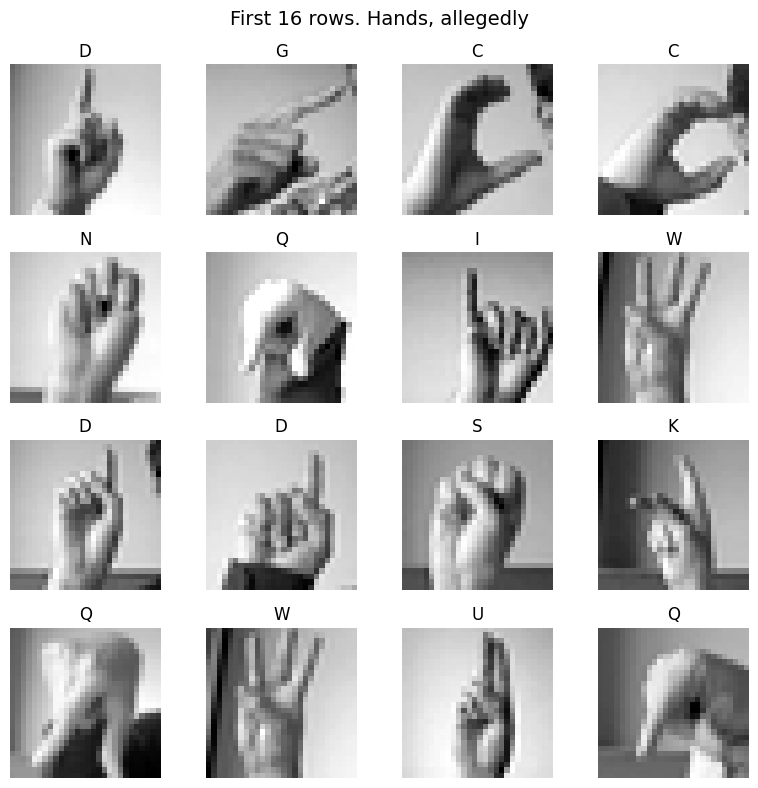

In [50]:
def raw_to_letter(y):
  return chr(ord("A") + int(y))
  # 4 * 4
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
plt.suptitle("First 16 rows. Hands, allegedly", fontsize=14)

for i, ax in enumerate(axes.flat):
  row = train_df.iloc[i]
  img = row.iloc[1:].values.astype(np.float32).reshape(28, 28)
  ax.imshow(img, cmap="gray")
  ax.set_title(raw_to_letter(row["label"]))
  ax.axis("off")

plt.tight_layout()
plt.show()

# 3. The J-shaped pothole

In [51]:
def remap_label(y):
  y = int(y)
  if y > 9:
    y = y-1
  return y

LETTERS = [chr(ord("A") + i) for i in range(26) if i not in (9, 25)]  #A-Z, i,j not in
idx_to_letter = {i: ch for i, ch in enumerate(LETTERS)}
print("24 Letters the mode is allowed to guess: ", "".join(LETTERS))

def remap_frame(df):
  out = df.copy()
  out["label"] = out["label"].map(remap_label)
  return out
train_df = remap_frame(train_df)
test_df = remap_frame(test_df)

train_df.head()

24 Letters the mode is allowed to guess:  ABCDEFGHIKLMNOPQRSTUVWXY


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,12,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


# 4. Subset so class ends this century

In [52]:
# Pick n random rows from every letter, same seed every run.
SAMPLES_PER_CLASS = 100
SEED = 42

def subset_per_class(df, n, seed=SEED):
    parts = []
    for _, group in df.groupby("label"):

        take = min(n, len(group))

        parts.append(group.sample(n=take, random_state=seed))

    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)


all_df = pd.concat([train_df, test_df], ignore_index=True)
small_df = subset_per_class(all_df, SAMPLES_PER_CLASS)

X = small_df.iloc[:, 1:].values
y = small_df.iloc[:, 0].values.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"subset: {len(small_df)}  ({SAMPLES_PER_CLASS} x 24 = {SAMPLES_PER_CLASS * 24})")
print(f"train: {len(X_train)}   test: {len(X_test)}")
print("stratify=y so we did not dump all the A's into train by accident.")

subset: 2400  (100 x 24 = 2400)
train: 1920   test: 480
stratify=y so we did not dump all the A's into train by accident.


# 5. Pixels into [0, 1]

In [53]:
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print("X_train", X_train.shape, X_train.min(), X_train.max())
print("y_train", y_train.shape, y_train.min(), y_train.max())
print("X_test", X_test.shape)
print("One row is 784 floats. a picture, legally speaking.")

X_train (1920, 784) 0.0 1.0
y_train (1920,) 0 23
X_test (480, 784)
One row is 784 floats. a picture, legally speaking.


# 6. Custom Dataset

In [54]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]


train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

x0, y0 = train_dataset[0]
print("One sample ->", tuple(x0.shape), "  Letter", idx_to_letter[int(y0)])
print("Len train/test:", len(train_dataset), len(test_dataset))

One sample -> (784,)   Letter B
Len train/test: 1920 480


# 7. DataLoader

In [55]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle = True, pin_memory=use_cuda
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=use_cuda
)

xb, yb = next(iter(train_loader))
print("Batch X: ", tuple(xb.shape), " -> [B, 784]")
print("Batch y: ", tuple(yb.shape), " -> [B]")
print("letters: ", [idx_to_letter[int(i)] for i in yb[:8]], "...")
print("train batches: ", len(train_loader), "   test batches: ", len(test_loader))


Batch X:  (32, 784)  -> [B, 784]
Batch y:  (32,)  -> [B]
letters:  ['Y', 'G', 'L', 'R', 'P', 'R', 'N', 'G'] ...
train batches:  60    test batches:  15


# 8. The ANN (a.k.a. a stack of matrix multiplies)

In [56]:
class MyNN(nn.Module):
  def __init__(self, num_features, num_classes):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, num_classes),
    )

  def forward(self, x):
    return self.model(x)

num_features = X_train.shape[1]
num_classes = 24
model = MyNN(num_features, num_classes).to(device)
print(model)

dummy = torch.randn(2, num_features, device=device)

with torch.no_grad():
  logits = model(dummy)

print("dummy in: ", tuple(dummy.shape))
print(f"logits out: {tuple(logits.shape)}  <- 24 scores, not 10, not 26")

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=24, bias=True)
  )
)
dummy in:  (2, 784)
logits out: (2, 24)  <- 24 scores, not 10, not 26


# 9. Train

In [57]:
learning_rate = 0.1
epochs = 20

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), learning_rate)

train_losses = []

for epoch in range(epochs):
  model.train()
  total_epoch_loss = 0.0

  for batch_features, batch_labels in train_loader:
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    optimizer.zero_grad()
    outputs = model(batch_features)
    loss = criterion(outputs, batch_labels)
    loss.backward()
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_loss = total_epoch_loss / len(train_loader)
  train_losses.append(avg_loss)
  print(f"Epoch: {epoch+1}, Loss: {avg_loss:.4f}")

print("\ndone. if you expected fluent ASL, that is a different course.")

Epoch: 1, Loss: 3.1681
Epoch: 2, Loss: 3.0819
Epoch: 3, Loss: 2.9539
Epoch: 4, Loss: 2.8016
Epoch: 5, Loss: 2.7005
Epoch: 6, Loss: 2.5493
Epoch: 7, Loss: 2.4307
Epoch: 8, Loss: 2.3851
Epoch: 9, Loss: 2.2571
Epoch: 10, Loss: 2.2519
Epoch: 11, Loss: 2.1890
Epoch: 12, Loss: 2.2580
Epoch: 13, Loss: 2.1624
Epoch: 14, Loss: 1.9478
Epoch: 15, Loss: 1.8777
Epoch: 16, Loss: 1.7438
Epoch: 17, Loss: 1.7642
Epoch: 18, Loss: 1.7870
Epoch: 19, Loss: 1.6519
Epoch: 20, Loss: 1.8354

done. if you expected fluent ASL, that is a different course.


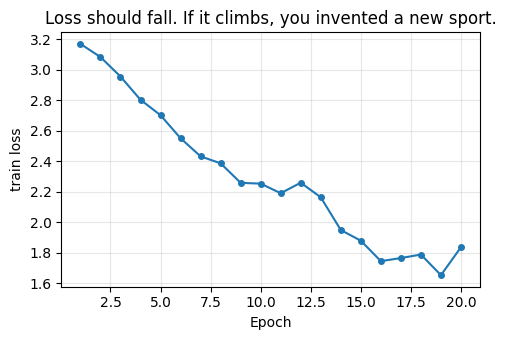

In [58]:
plt.figure(figsize = (5, 3.5))
plt.plot(range(1, epochs + 1), train_losses, marker = 'o', markersize=4)

plt.xlabel("Epoch")
plt.ylabel("train loss")
plt.title("Loss should fall. If it climbs, you invented a new sport.")

plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

# 10. Evaluation

In [59]:
def accuracy(loader):
  model.eval()
  correct = 0
  total = 0

  with torch.no_grad():
    for batch_features, batch_labels in loader:
      batch_features = batch_features.to(device)
      batch_labels = batch_labels.to(device)

      predicted = model(batch_features).argmax(dim = 1)
      total += batch_labels.shape[0]

      correct += (predicted == batch_labels).sum().item()

  return correct / total


test_acc = accuracy(test_loader)
train_acc = accuracy(train_loader)
chance = 1.0 / num_classes

print(f"test accuracy: {test_acc:.3f}    ({100 * test_acc:.1f}%)")
print(f"train accuracy: {train_acc:.3f}   ({100 * train_acc:.1f}%)")
print(f"random guessing: {chance:.3f}     ({100 * chance:.1f}%)")

test accuracy: 0.483    (48.3%)
train accuracy: 0.567   (56.7%)
random guessing: 0.042     (4.2%)


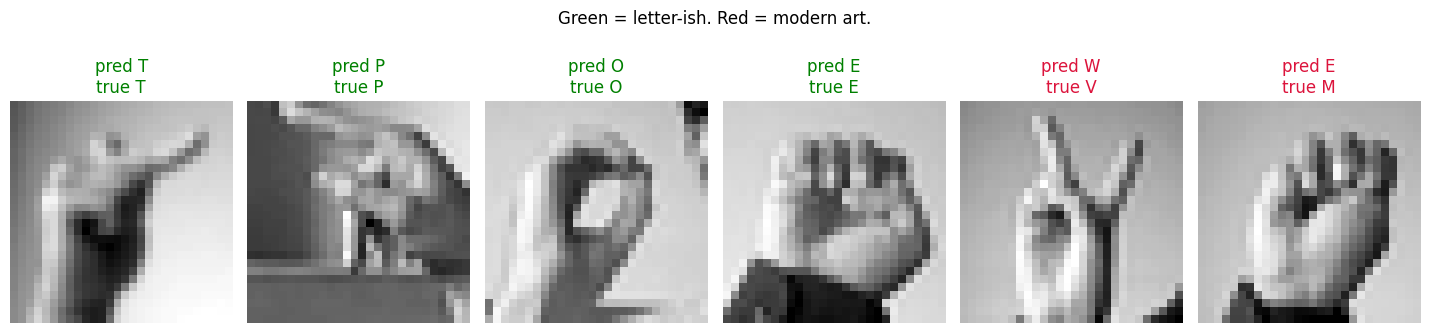

In [60]:
N_SHOW = 6

vis_x, vis_y = next(iter(test_loader))
vis_x = vis_x[:N_SHOW]
vis_y = vis_y[:N_SHOW]

model.eval()
with torch.no_grad():
    preds = model(vis_x.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(1, N_SHOW, figsize=(2.4 * N_SHOW, 3.2))
for ax, flat, true_y, pred_y in zip(axes, vis_x, vis_y, preds):
    ax.imshow(flat.reshape(28, 28), cmap="gray")
    true_ch = idx_to_letter[int(true_y)]
    pred_ch = idx_to_letter[int(pred_y)]
    ok = pred_y == true_y
    ax.set_title(f"pred {pred_ch}\ntrue {true_ch}", color=("green" if ok else "crimson"))
    ax.axis("off")

# Caption above the row of pictures.
plt.suptitle("Green = letter-ish. Red = modern art.", y=1.08)
plt.tight_layout()
plt.show()